# **1. Mengunduh dan Mengekstrak File ZIP Dataset**

In [2]:
# 1. Instalasi library
!pip install -q split-folders gdown pillow-heif

import gdown
import zipfile
import os
import glob

file_id = '1VHA-PIYJdG0wGfNRYIfTwQSpvaEhysrT'
url = f'https://drive.google.com/uc?id={file_id}'

output_zip = '/kaggle/working/dataset_raw.zip'
extract_dir = '/kaggle/working/dataset_raw'

print("=========================================================")
print("--- MENGUNDUH FILE ZIP DATASET DARI GOOGLE DRIVE ---")
print("=========================================================")

gdown.download(url, output_zip, quiet=False)

print("\n=========================================================")
print("--- MEMULAI PROSES EKSTRAKSI FILE ZIP ---")
print("=========================================================")

# Mengekstrak file zip ke folder lokal Kaggle
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Ekstraksi selesai!")

# Cek isi folder hasil ekstraksi untuk memastikan folder 'mobil' dan 'motor' aman
print("\nDaftar direktori yang berhasil diekstrak:")
for root, dirs, files in os.walk(extract_dir):
    if len(dirs) > 0:
        print(f"Lokasi: {root} -> Berisi folder: {dirs}")

--- MENGUNDUH FILE ZIP DATASET DARI GOOGLE DRIVE ---


Downloading...
From (original): https://drive.google.com/uc?id=1VHA-PIYJdG0wGfNRYIfTwQSpvaEhysrT
From (redirected): https://drive.google.com/uc?id=1VHA-PIYJdG0wGfNRYIfTwQSpvaEhysrT&confirm=t&uuid=92b20ce1-cfe2-4af8-b4ca-01de7e910ad5
To: /kaggle/working/dataset_raw.zip
100%|██████████| 43.4M/43.4M [00:01<00:00, 42.2MB/s]


--- MEMULAI PROSES EKSTRAKSI FILE ZIP ---
Ekstraksi selesai!

Daftar direktori yang berhasil diekstrak:
Lokasi: /kaggle/working/dataset_raw -> Berisi folder: ['mobil vs motor']
Lokasi: /kaggle/working/dataset_raw/mobil vs motor -> Berisi folder: ['motor', 'mobil']


# **Cell 2: Standardisasi Format Gambar & Rename Berurutan**

In [3]:
from PIL import Image
import pillow_heif
import os

# Daftarkan penanganan format HEIF/HEIC ke Pillow
pillow_heif.register_heif_opener()

# Path folder mentah hasil unduhan dari Drive
base_dataset_dir = '/kaggle/working/dataset_raw'
subfolders = [os.path.join(base_dataset_dir, f) for f in os.listdir(base_dataset_dir) if os.path.isdir(os.path.join(base_dataset_dir, f))]

# Deteksi jika folder terbungkus (nested folder) saat diekstrak
if len(subfolders) == 1 and ('mobil' not in os.listdir(base_dataset_dir)):
    source_dir = subfolders[0]
else:
    source_dir = base_dataset_dir

# Buat folder 'gabungan' murni (flat tanpa subfolder mobil/motor di dalamnya)
output_gabungan_dir = '/kaggle/working/gabungan'
os.makedirs(output_gabungan_dir, exist_ok=True)

print(f"✓ Folder tujuan sukses dibuat: {output_gabungan_dir}")

# Ekstensi gambar yang valid untuk diproses
valid_extensions = ('.heic', '.heif', '.png', '.webp', '.jpeg', '.jpg', '.PNG', '.JPEG', '.JPG', '.HEIC')

# Fungsi untuk memproses kloning, konversi, dan penamaan ulang langsung ke satu folder
def process_and_rename_flat(class_name, target_save_dir):
    source_class_dir = os.path.join(source_dir, class_name)
    
    if not os.path.exists(source_class_dir):
        print(f"⚠ Peringatan: Folder asal untuk kelas '{class_name}' tidak ditemukan.")
        return 0
    
    counter = 1
    files = os.listdir(source_class_dir)
    
    for file in files:
        file_path = os.path.join(source_class_dir, file)
        
        if os.path.isfile(file_path):
            _, file_ext = os.path.splitext(file)
            
            if file_ext.lower() in valid_extensions:
                try:
                    img = Image.open(file_path)
                    
                    # Pastikan diconvert ke RGB murni agar format warna seragam
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    
                    # Berkas disimpan di /gabungan/mobil1.jpg atau /gabungan/motor1.jpg
                    new_filename = f"{class_name}{counter}.jpg"
                    new_file_path = os.path.join(target_save_dir, new_filename)
                    
                    img.save(new_file_path, 'JPEG', quality=90)
                    counter += 1
                    
                except Exception as e:
                    print(f"⚠ Gagal memproses file {file} di kelas {class_name}: {str(e)}")
                    
    return counter - 1

# Eksekusi proses untuk kedua kelas kendaraan
print("\n--- Memulai Standardisasi & Rename Gambar ---")
total_mobil = process_and_rename_flat('mobil', output_gabungan_dir)
print(f"✓ Sukses mengonversi dan me-rename {total_mobil} gambar mobil -> dimasukkan ke folder gabungan/")

total_motor = process_and_rename_flat('motor', output_gabungan_dir)
print(f"✓ Sukses mengonversi dan me-rename {total_motor} gambar motor -> dimasukkan ke folder gabungan/")

print(f"\nTotal keseluruhan data di folder gabungan murni: {len(os.listdir(output_gabungan_dir))} file .jpg")

✓ Folder tujuan sukses dibuat: /kaggle/working/gabungan

--- Memulai Standardisasi & Rename Gambar ---
✓ Sukses mengonversi dan me-rename 55 gambar mobil -> dimasukkan ke folder gabungan/
✓ Sukses mengonversi dan me-rename 83 gambar motor -> dimasukkan ke folder gabungan/

Total keseluruhan data di folder gabungan murni: 138 file .jpg


# **Proses Augmentasi Fisik (Offline) ke Folder Gabungan**

In [26]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from PIL import Image

# Tentukan target jumlah data fisik akhir yang kamu inginkan per kelas
# Menambah data fisik secara signifikan membantu CNN Baseline keluar dari zona underfitting
TARGET_PER_KELAS = 600 

folder_gabungan = '/kaggle/working/gabungan'
all_files = os.listdir(folder_gabungan)

# Definisikan generator augmentasi internal khusus untuk memproduksi file fisik
offline_dg = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

print("=========================================================")
print("      PROSES GENERATE AUGMENTASI FISIK (OFFLINE)         ")
print("=========================================================")

for kelas in ['mobil', 'motor']:
    files_kelas = [f for f in all_files if f.startswith(kelas)]
    jumlah_sekarang = len(files_kelas)
    
    if jumlah_sekarang < TARGET_PER_KELAS:
        kekurangan = TARGET_PER_KELAS - jumlah_sekarang
        print(f"➔ Kelas {kelas.upper()}: Jumlah asli {jumlah_sekarang} file. Menambah {kekurangan} file augmentasi baru...")
        
        counter_save = jumlah_sekarang + 1
        
        for i in range(kekurangan):
            # Pilih 1 gambar asli secara acak sebagai core objek cetakan
            file_pilihan = np.random.choice(files_kelas)
            img = load_img(os.path.join(folder_gabungan, file_pilihan), target_size=(224, 224))
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)
            
            # Ambil 1 hasil modifikasi acak dari generator
            iterator = offline_dg.flow(x, batch_size=1)
            batch = next(iterator)
            img_hasil = batch[0]
            
            # Beri nama kelanjutan (misal: mobil201.jpg, mobil202.jpg dst)
            nama_file_baru = f"{kelas}{counter_save}.jpg"
            path_save = os.path.join(folder_gabungan, nama_file_baru)
            
            # Simpan secara fisik ke folder gabungan
            img_save_ready = img_hasil.astype(np.uint8)
            Image.fromarray(img_save_ready).save(path_save, 'JPEG', quality=90)
            
            counter_save += 1
    else:
        print(f"✓ Kelas {kelas.upper()} sudah memiliki {jumlah_sekarang} gambar (melebihi target). Tidak dilakukan augmentasi fisik.")

print(f"\n✓ SELESAI! Sekarang total file fisik di folder gabungan menjadi: {len(os.listdir(folder_gabungan))} gambar.")

      PROSES GENERATE AUGMENTASI FISIK (OFFLINE)         
➔ Kelas MOBIL: Jumlah asli 55 file. Menambah 545 file augmentasi baru...
➔ Kelas MOTOR: Jumlah asli 83 file. Menambah 517 file augmentasi baru...

✓ SELESAI! Sekarang total file fisik di folder gabungan menjadi: 1200 gambar.


# **2b: Proses Stratified Split Manual (70:15:15)**

In [27]:
import shutil
from sklearn.model_selection import train_test_split

# 1. Kumpulkan semua file dan labelnya dari folder gabungan
all_files = os.listdir(output_gabungan_dir)
files_list = []
labels_list = []

for f in all_files:
    if f.startswith('mobil'):
        files_list.append(f)
        labels_list.append('mobil')
    elif f.startswith('motor'):
        files_list.append(f)
        labels_list.append('motor')

# 2. Proses Pembagian Data (70% Train, 15% Val, 15% Test)
# Pisahkan Train (70%) dan Sisa (30%) terlebih dahulu
X_train, X_temp, y_train, y_temp = train_test_split(
    files_list, labels_list, test_size=0.30, random_state=1008, stratify=labels_list
)

# Pisahkan Sisa (30%) menjadi Val (15%) dan Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=1008, stratify=y_temp
)

# 3. Buat direktori tujuan split akhir untuk ImageDataGenerator
output_split_folder = '/kaggle/working/dataset_split'
for split in ['train', 'val', 'test']:
    for class_label in ['mobil', 'motor']:
        os.makedirs(os.path.join(output_split_folder, split, class_label), exist_ok=True)

# Fungsi bantu untuk menyalin file ke tempat split masing-masing
def copy_split_files(files, split_name):
    for f in files:
        label = 'mobil' if f.startswith('mobil') else 'motor'
        src = os.path.join(output_gabungan_dir, f)
        dst = os.path.join(output_split_folder, split_name, label, f)
        shutil.copy(src, dst)

# Eksekusi penyalinan file
copy_split_files(X_train, 'train')
copy_split_files(X_val, 'val')
copy_split_files(X_test, 'test')

print("=========================================================================")
print("✓ DATASET BERHASIL DI-SPLIT STRATIFIED DARI FOLDER GABUNGAN MURNI!")
print("=========================================================================\n")

# Verifikasi jumlah data akhir untuk validasi bab metodologi penelitian kamu
for split in ['train', 'val', 'test']:
    print(f"--- Subset {split.upper()} ---")
    for kelas in ['mobil', 'motor']:
        path_cek = os.path.join(output_split_folder, split, kelas)
        print(f"Jumlah file di kelas '{kelas}': {len(os.listdir(path_cek))} gambar (.jpg)")

✓ DATASET BERHASIL DI-SPLIT STRATIFIED DARI FOLDER GABUNGAN MURNI!

--- Subset TRAIN ---
Jumlah file di kelas 'mobil': 434 gambar (.jpg)
Jumlah file di kelas 'motor': 443 gambar (.jpg)
--- Subset VAL ---
Jumlah file di kelas 'mobil': 98 gambar (.jpg)
Jumlah file di kelas 'motor': 102 gambar (.jpg)
--- Subset TEST ---
Jumlah file di kelas 'mobil': 97 gambar (.jpg)
Jumlah file di kelas 'motor': 99 gambar (.jpg)


# **3: Preprocessing & Data Augmentation Pipeline**

In [28]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# KINI HANYA RESCALE (Normalisasi Skala) karena augmentasi variasi objek sudah terkunci permanen di folder fisik
train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("--- Loading Data Training ---")
train_generator = train_datagen.flow_from_directory(
    '/kaggle/working/dataset_split/train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

print("\n--- Loading Data Validasi ---")
val_generator = val_test_datagen.flow_from_directory(
    '/kaggle/working/dataset_split/val',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n--- Loading Data Testing ---")
test_generator = val_test_datagen.flow_from_directory(
    '/kaggle/working/dataset_split/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\nIndeks Kelas Terdeteksi: {train_generator.class_indices}")

--- Loading Data Training ---
Found 877 images belonging to 2 classes.

--- Loading Data Validasi ---
Found 200 images belonging to 2 classes.

--- Loading Data Testing ---
Found 196 images belonging to 2 classes.

Indeks Kelas Terdeteksi: {'mobil': 0, 'motor': 1}


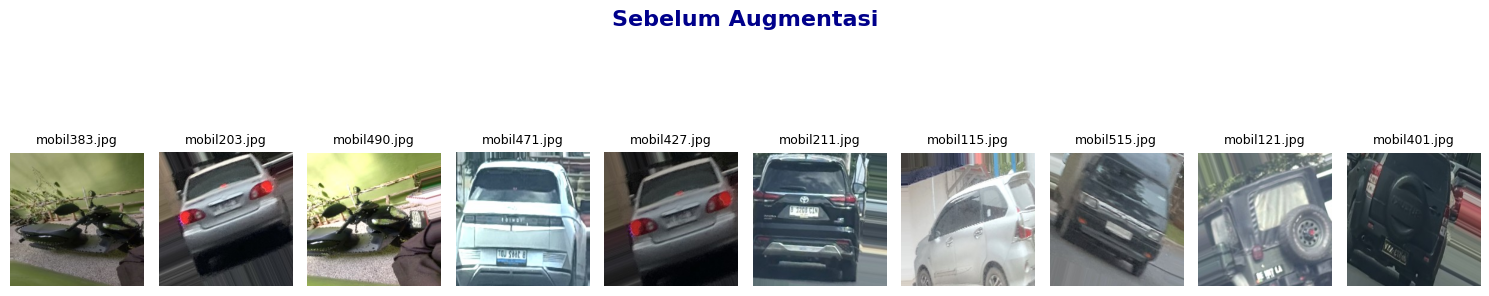

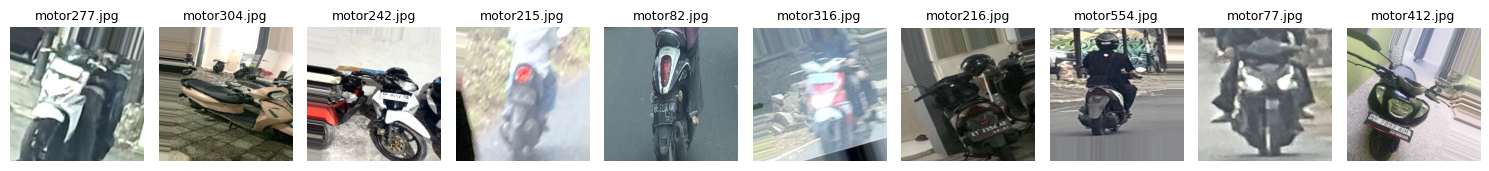

In [29]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
import os
import random

folder_gabungan = '/kaggle/working/gabungan'
all_files = os.listdir(folder_gabungan)

# Filter file berdasarkan nama kelas
mobil_files = [f for f in all_files if f.startswith('mobil')]
motor_files = [f for f in all_files if f.startswith('motor')]

# Ambil masing-masing 10 sampel secara acak
sampel_mobil = random.sample(mobil_files, min(10, len(mobil_files)))
sampel_motor = random.sample(motor_files, min(10, len(motor_files)))

# Plot 10 Sampel Mobil Asli
plt.figure(figsize=(15, 4))
plt.suptitle("Sebelum Augmentasi", fontsize=16, fontweight='bold', color='darkblue')
for i, file_name in enumerate(sampel_mobil):
    plt.subplot(1, 10, i + 1)
    img = load_img(os.path.join(folder_gabungan, file_name), target_size=(224, 224))
    plt.imshow(img)
    plt.title(file_name, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Plot 10 Sampel Motor Asli
plt.figure(figsize=(15, 4))
for i, file_name in enumerate(sampel_motor):
    plt.subplot(1, 10, i + 1)
    img = load_img(os.path.join(folder_gabungan, file_name), target_size=(224, 224))
    plt.imshow(img)
    plt.title(file_name, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

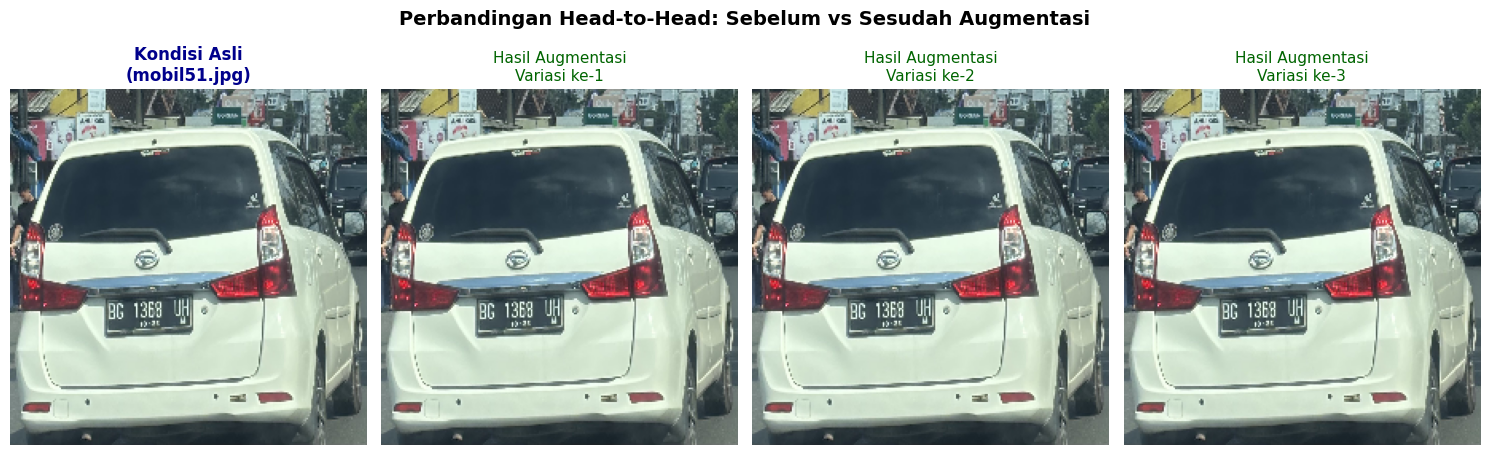

In [30]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import random
import os

folder_gabungan = '/kaggle/working/gabungan'
semua_gambar = os.listdir(folder_gabungan)
gambar_sampel = random.choice(semua_gambar)
path_gambar_sampel = os.path.join(folder_gabungan, gambar_sampel)

# Load gambar asli
img_asli = load_img(path_gambar_sampel, target_size=(224, 224))
img_array = img_to_array(img_asli)  
img_array_expanded = np.expand_dims(img_array, axis=0) 

# Generate 3 variasi teknik augmentasi secara acak
augmented_images = []
iterator = train_datagen.flow(img_array_expanded, batch_size=1)

for _ in range(3):
    batch = next(iterator)
    image = batch[0] 
    augmented_images.append(image)

# Plot Perbandingan
plt.figure(figsize=(15, 5))
plt.suptitle("Perbandingan Head-to-Head: Sebelum vs Sesudah Augmentasi", fontsize=14, fontweight='bold')

# Kolom 1: Asli
plt.subplot(1, 4, 1)
plt.imshow(img_asli)
plt.title(f"Kondisi Asli\n({gambar_sampel})", fontsize=12, color='darkblue', fontweight='bold')
plt.axis('off')

# Kolom 2-4: Hasil Transformasi Augmentasi
for i, img_aug in enumerate(augmented_images):
    plt.subplot(1, 4, i + 2)
    plt.imshow(img_aug)
    plt.title(f"Hasil Augmentasi\nVariasi ke-{i+1}", fontsize=11, color='darkgreen')
    plt.axis('off')

plt.tight_layout()
plt.show()

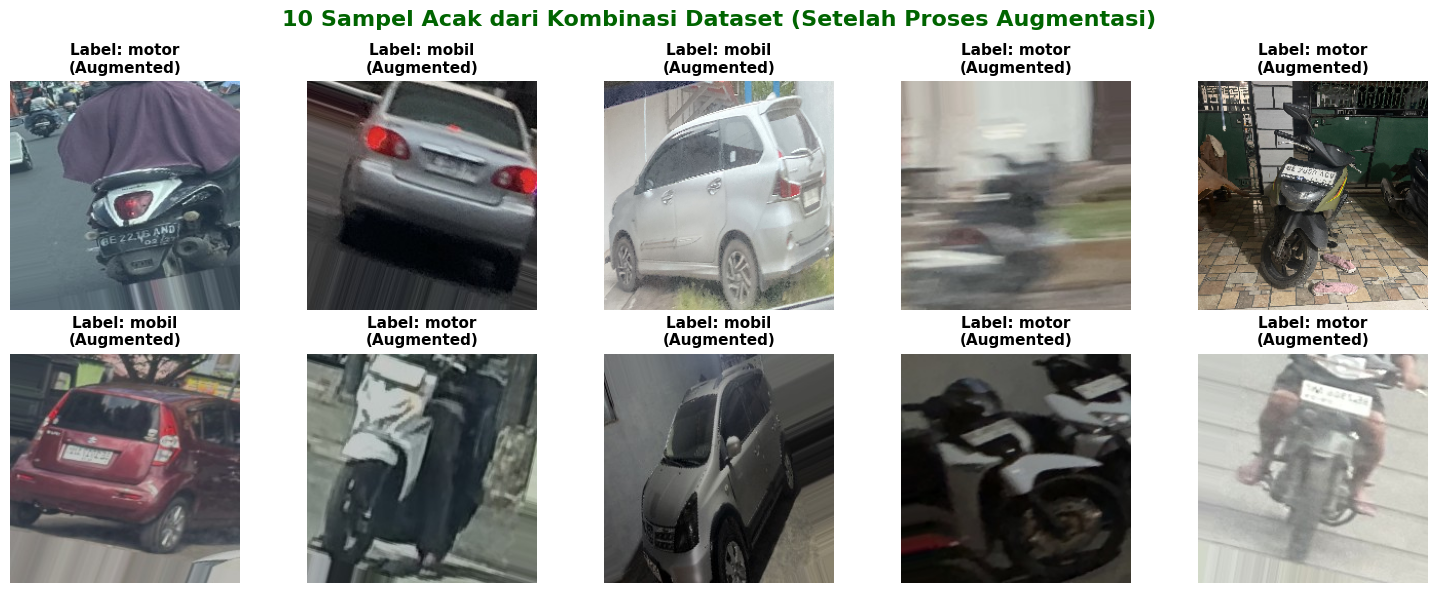

In [31]:
import matplotlib.pyplot as plt

# Mengambil satu batch data acak dari train_generator
# Karena batch_size = 32, kita bisa mengambil 10 gambar pertama dari batch tersebut
images_batch, labels_batch = next(train_generator)

# Ambil pemetaan indeks kelas (0 untuk kelas pertama, 1 untuk kelas kedua)
labels_map = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(15, 6))
plt.suptitle("10 Sampel Acak dari Kombinasi Dataset (Setelah Proses Augmentasi)", fontsize=16, fontweight='bold', color='darkgreen')

# Menampilkan 10 gambar hasil transformasi augmentasi secara berjejer
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images_batch[i])
    
    # Deteksi label biner asli dari gambar tersebut
    class_label = labels_map[int(labels_batch[i])]
    plt.title(f"Label: {class_label}\n(Augmented)", fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

# **4: Model Factory (Definisi 3 Arsitektur Jaringan)**

In [32]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50

# --- MODEL 1: CNN BASELINE (Membangun dari Nol) ---
def build_baseline_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),                    
        layers.Dense(1, activation='sigmoid')   
    ])
    return model

# --- MODEL 2: MOBILENETV2 (Transfer Learning) ---
def build_mobilenet_model():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model, base_model

# --- MODEL 3: RESNET50 (Transfer Learning) ---
def build_resnet_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    return model, base_model

# **5: Konfigurasi Callbacks Medis & Akademis**

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def get_callbacks(model_name):
    return [
        # Menghentikan latihan jika val_loss tidak membaik selama 5 epoch berturut-turut
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        
        # Hanya menyimpan berkas model (.h5) yang menghasilkan val_loss terkecil (Paling Bagus)
        ModelCheckpoint(filepath=f'{model_name}_best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
    ]

# **Cell 6: Eksperimen Pelatihan - Model 1: CNN Baseline**

In [34]:
baseline_model = build_baseline_model()
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("==========================================")
print("     MEMULAI TRAINING: CNN BASELINE       ")
print("==========================================")

history_baseline = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=get_callbacks('cnn_baseline')
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


     MEMULAI TRAINING: CNN BASELINE       
Epoch 1/30
20/28 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5160 - loss: 1.1732

2026-05-27 05:52:54.467184: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 05:52:54.611895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.5170 - loss: 1.0882
Epoch 1: val_loss improved from inf to 0.67036, saving model to cnn_baseline_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 410ms/step - accuracy: 0.5175 - loss: 1.0798 - val_accuracy: 0.6300 - val_loss: 0.6704
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.6519 - loss: 0.6223
Epoch 2: val_loss improved from 0.67036 to 0.49029, saving model to cnn_baseline_best_model.h5


...

28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.7521 - loss: 0.4960 - val_accuracy: 0.7850 - val_loss: 0.4564
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8204 - loss: 0.3913
Epoch 4: val_loss improved from 0.45642 to 0.37398, saving model to cnn_baseline_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.8203 - loss: 0.3910 - val_accuracy: 0.8600 - val_loss: 0.3740
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.8366 - loss: 0.3559
Epoch 5: val_loss improved from 0.37398 to 0.33502, saving model to cnn_baseline_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.8374 - loss: 0.3547 - val_accuracy: 0.8650 - val_loss: 0.3350
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8520 - loss: 0.3120
Epoch 6: val_loss improved from 0.33502 to 0.31815, saving model to cnn_baseline_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.8527 - loss: 0.3116 - val_accuracy: 0.8800 - val_loss: 0.3182
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9053 - loss: 0.2336
Epoch 7: val_loss did not improve from 0.31815
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.9055 - loss: 0.2334 - val_accuracy: 0.8200 - val_loss: 0.4159
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8937 - loss: 0.2165
Epoch 8: val_loss did not improve from 0.31815
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.8941 - loss: 0.2163 - val_accuracy: 0.8800 - val_loss: 0.3483
Epoch 9/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9393 - loss: 0.1386
Epoch 9: val_loss did not improve from 0.31815
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.9395 - loss: 0.1386 - val_accuracy: 0.9000 - val_loss: 0.3265
Epoch 10/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9426 - loss: 0.1346
Epoch 10: val_loss did not improve from 0.31815

28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.9615 - loss: 0.1093 - val_accuracy: 0.8800 - val_loss: 0.3174
Epoch 12/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9695 - loss: 0.0865
Epoch 12: val_loss did not improve from 0.31737
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.9693 - loss: 0.0867 - val_accuracy: 0.8800 - val_loss: 0.4389
Epoch 13/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9773 - loss: 0.0589
Epoch 13: val_loss did not improve from 0.31737
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.9773 - loss: 0.0591 - val_accuracy: 0.8800 - val_loss: 0.4138
Epoch 14/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9754 - loss: 0.0682
Epoch 14: val_loss did not improve from 0.31737
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.9754 - loss: 0.0682 - val_accuracy: 0.8950 - val_loss: 0.4892
Epoch 15/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9800 - loss: 0.0555
Epoch 15: val_loss did not improve from 

# **7: Eksperimen Pelatihan - Model 2: MobileNetV2 (Skema 2 Tahap)**

In [35]:
mobilenet_model, mobilenet_base = build_mobilenet_model()

# ----------- TAHAP 1: FEATURE EXTRACTION -----------
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("==========================================")
print("   MOBILENETV2 - TAHAP 1: FEATURE EXTRACT  ")
print("==========================================")
_ = mobilenet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# ----------- TAHAP 2: FINE-TUNING -----------
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-20]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n==========================================")
print("     MOBILENETV2 - TAHAP 2: FINE-TUNING    ")
print("==========================================")
history_mobilenet = mobilenet_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=get_callbacks('mobilenetv2')
)

   MOBILENETV2 - TAHAP 1: FEATURE EXTRACT  
Epoch 1/10
 4/28 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5990 - loss: 0.6853

2026-05-27 05:54:28.307007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 05:54:28.443690: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 05:54:28.580379: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.8360 - loss: 0.3581

2026-05-27 05:54:46.537765: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 05:54:46.674592: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8389 - loss: 0.3529 - val_accuracy: 0.9850 - val_loss: 0.0425
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.9828 - loss: 0.0621 - val_accuracy: 0.9900 - val_loss: 0.0240
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.9903 - loss: 0.0343 - val_accuracy: 0.9950 - val_loss: 0.0293
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9921 - loss: 0.0383 - val_accuracy: 0.9950 - val_loss: 0.0210
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.9847 - loss: 0.0380 - val_accuracy: 0.9950 - val_loss: 0.0166
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9906 - loss: 0.0230 - val_accuracy: 0.9950 - val_loss: 0.0133
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9842 - loss: 0.0309 - val_accuracy: 0.9950 - val_loss: 0.0144
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.9964 - loss: 0.0134 - val_accuracy: 0.9950 - val_lo

...

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.9965 - loss: 0.0063 - val_accuracy: 0.9900 - val_loss: 0.0174
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9970 - loss: 0.0066
Epoch 8: val_loss improved from 0.01737 to 0.01414, saving model to mobilenetv2_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.9970 - loss: 0.0068 - val_accuracy: 0.9900 - val_loss: 0.0141
Epoch 9/20
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9976 - loss: 0.0057
Epoch 9: val_loss improved from 0.01414 to 0.01392, saving model to mobilenetv2_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.9975 - loss: 0.0059 - val_accuracy: 0.9950 - val_loss: 0.0139
Epoch 10/20
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9969 - loss: 0.0056
Epoch 10: val_loss improved from 0.01392 to 0.01254, saving model to mobilenetv2_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.9969 - loss: 0.0056 - val_accuracy: 0.9900 - val_loss: 0.0125
Epoch 11/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9978 - loss: 0.0041
Epoch 11: val_loss improved from 0.01254 to 0.01146, saving model to mobilenetv2_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.9978 - loss: 0.0041 - val_accuracy: 0.9950 - val_loss: 0.0115
Epoch 12/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9981 - loss: 0.0058
Epoch 12: val_loss did not improve from 0.01146
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.9981 - loss: 0.0058 - val_accuracy: 0.9900 - val_loss: 0.0171
Epoch 13/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9967 - loss: 0.0069
Epoch 13: val_loss did not improve from 0.01146
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.9967 - loss: 0.0069 - val_accuracy: 0.9950 - val_loss: 0.0125
Epoch 14/20
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9958 - loss: 0.0093
Epoch 14: val_loss did not improve from 0.01146
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.9958 - loss: 0.0093 - val_accuracy: 0.9850 - val_loss: 0.0212
Epoch 15/20
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 1.0000 - loss: 0.0040
Epoch 15: val_loss did not improve from 0

# **8:Eksperimen Pelatihan - Model 3: ResNet50 (Skema 2 Tahap)**

In [36]:
resnet_model, resnet_base = build_resnet_model()

# ----------- TAHAP 1: FEATURE EXTRACTION -----------
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("==========================================")
print("     RESNET50 - TAHAP 1: FEATURE EXTRACT   ")
print("==========================================")
_ = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# ----------- TAHAP 2: FINE-TUNING -----------
resnet_base.trainable = True
for layer in resnet_base.layers:
    if 'conv5_' not in layer.name and 'res5' not in layer.name:
        layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n==========================================")
print("       RESNET50 - TAHAP 2: FINE-TUNING     ")
print("==========================================")
history_resnet = resnet_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=get_callbacks('resnet50')
)

     RESNET50 - TAHAP 1: FEATURE EXTRACT   
Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 27s 588ms/step - accuracy: 0.4984 - loss: 0.7654 - val_accuracy: 0.5100 - val_loss: 0.6816
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.5467 - loss: 0.6996 - val_accuracy: 0.5850 - val_loss: 0.6536
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.5539 - loss: 0.6947 - val_accuracy: 0.5950 - val_loss: 0.6500
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.5903 - loss: 0.6678 - val_accuracy: 0.7200 - val_loss: 0.6421
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.5948 - loss: 0.6579 - val_accuracy: 0.5850 - val_loss: 0.6433
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.5868 - loss: 0.6638 - val_accuracy: 0.6900 - val_loss: 0.6310
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.5825 - loss: 0.6603 - val_accuracy: 0.6400 - val_loss: 0.6264
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accur

28/28 ━━━━━━━━━━━━━━━━━━━━ 37s 687ms/step - accuracy: 0.6148 - loss: 0.7595 - val_accuracy: 0.6350 - val_loss: 0.6176
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8467 - loss: 0.3509
Epoch 2: val_loss did not improve from 0.61757
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.8467 - loss: 0.3508 - val_accuracy: 0.5850 - val_loss: 0.6435
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9138 - loss: 0.2546
Epoch 3: val_loss did not improve from 0.61757
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.9137 - loss: 0.2545 - val_accuracy: 0.5450 - val_loss: 0.6722
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9442 - loss: 0.1919
Epoch 4: val_loss did not improve from 0.61757
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.9444 - loss: 0.1912 - val_accuracy: 0.5550 - val_loss: 0.6966
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9445 - loss: 0.1601
Epoch 5: val_loss did not improve from 0.61757

# **9:Visualisasi Kurva Evaluasi Training (Akurasi & Loss)**

=== Evaluasi Visual CNN Baseline ===


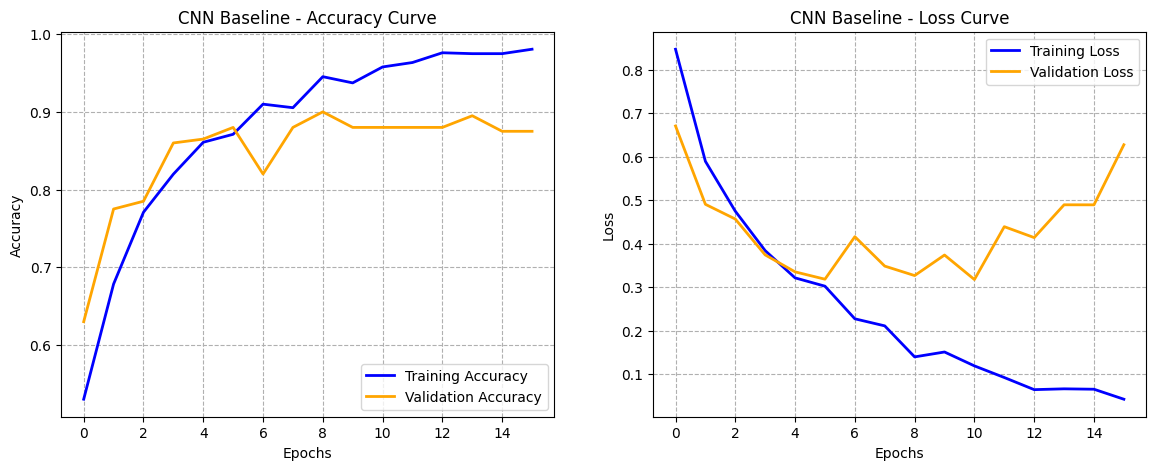


=== Evaluasi Visual MobileNetV2 (Fine-tuning) ===


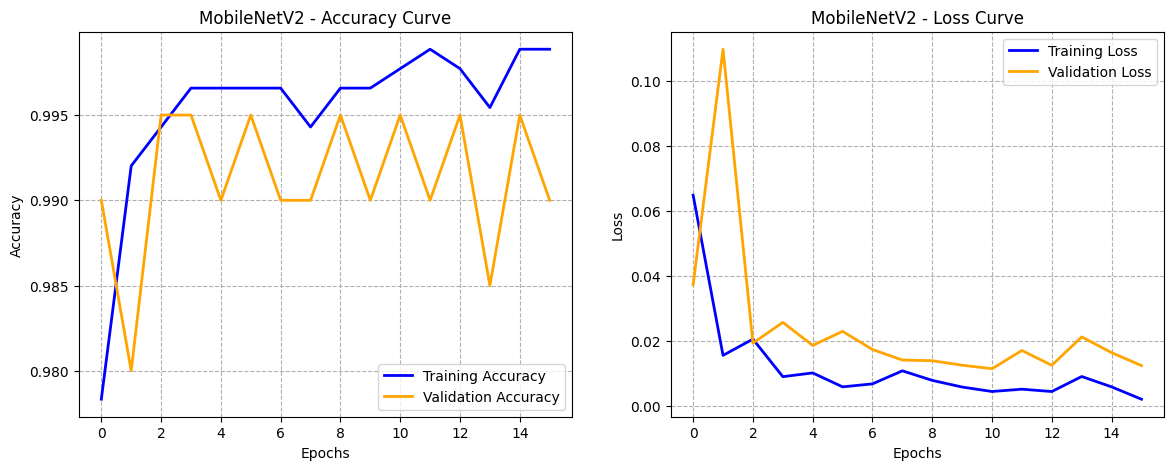


=== Evaluasi Visual ResNet50 (Fine-tuning) ===


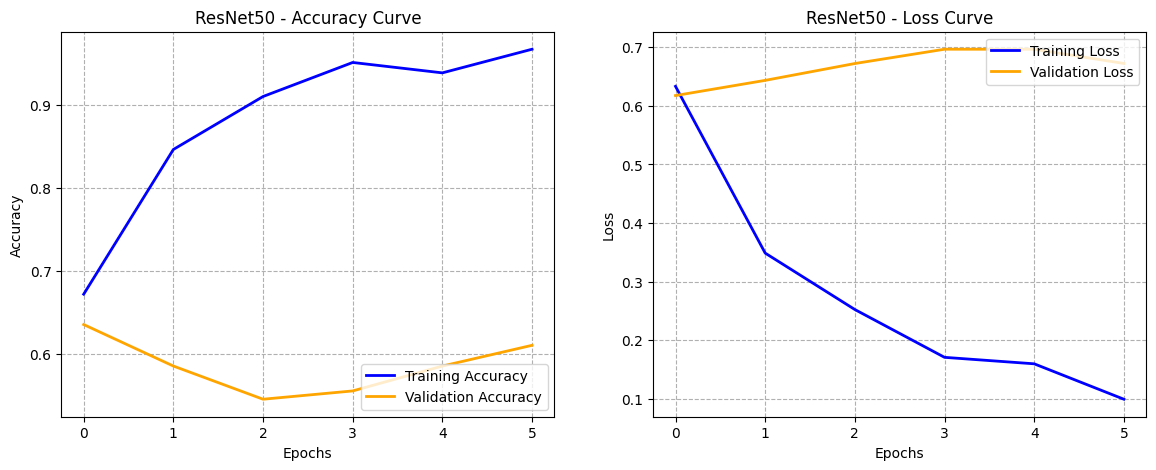

In [39]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', lw=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', lw=2)
    plt.title(f'{model_name} - Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue', lw=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', lw=2)
    plt.title(f'{model_name} - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--')

    plt.show()

print("=== Evaluasi Visual CNN Baseline ===")
plot_training_history(history_baseline, "CNN Baseline")

print("\n=== Evaluasi Visual MobileNetV2 (Fine-tuning) ===")
plot_training_history(history_mobilenet, "MobileNetV2")

print("\n=== Evaluasi Visual ResNet50 (Fine-tuning) ===")
plot_training_history(history_resnet, "ResNet50")


      EVALUASI AKHIR DATA TESTING: CNN Baseline        


6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/stepWARNING:tensorflow:5 out of the last 10 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7b9b5d3d9b20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step

--- Classification Performance Report ---
              precision    recall  f1-score   support

       mobil     0.8969    0.8969    0.8969        97
       motor     0.8990    0.8990    0.8990        99

    accuracy                         0.8980       196
   macro avg     0.8979    0.8979    0.8979       196
weighted avg     0.8980    0.8980    0.8980       196

--- Confusion Matrix ---


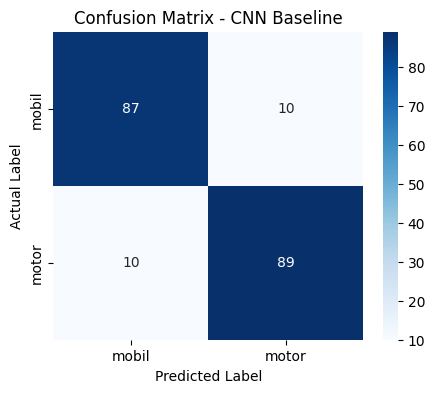


      EVALUASI AKHIR DATA TESTING: MobileNetV2        


6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step

2026-05-27 05:59:50.721225: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 05:59:50.857790: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step 

--- Classification Performance Report ---
              precision    recall  f1-score   support

       mobil     0.9895    0.9691    0.9792        97
       motor     0.9703    0.9899    0.9800        99

    accuracy                         0.9796       196
   macro avg     0.9799    0.9795    0.9796       196
weighted avg     0.9798    0.9796    0.9796       196

--- Confusion Matrix ---


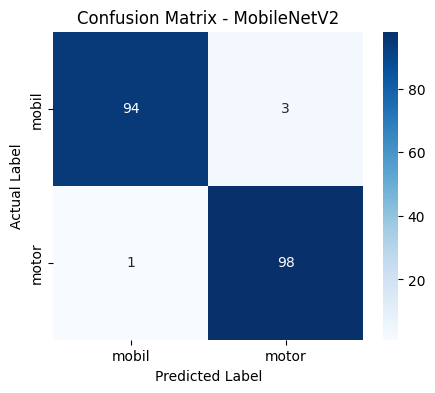


      EVALUASI AKHIR DATA TESTING: ResNet50        


7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 911ms/step

--- Classification Performance Report ---
              precision    recall  f1-score   support

       mobil     0.5641    0.9072    0.6957        97
       motor     0.7750    0.3131    0.4460        99

    accuracy                         0.6071       196
   macro avg     0.6696    0.6102    0.5708       196
weighted avg     0.6706    0.6071    0.5696       196

--- Confusion Matrix ---


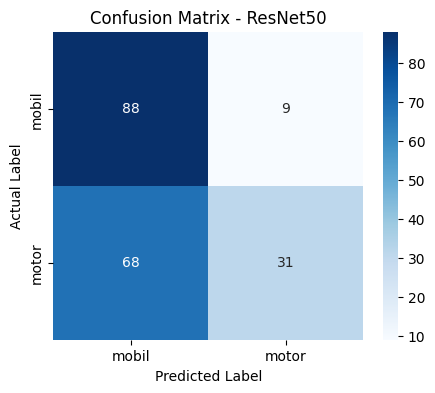

In [40]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_best_model(model_path, model_name):
    print(f"\n=======================================================")
    print(f"      EVALUASI AKHIR DATA TESTING: {model_name}        ")
    print(f"=======================================================")
    
    try:
        model = tf.keras.models.load_model(model_path)
    except:
        print(f"⚠ Gagal memuat berkas {model_path}. Pastikan file tersedia.")
        return

    # Prediksi menggunakan data generator testing
    predictions = model.predict(test_generator, verbose=1)
    
    # Konversi nilai kontinu sigmoid (>0.5 -> 1, jika tidak -> 0)
    y_pred = np.where(predictions > 0.5, 1, 0).flatten()
    y_true = test_generator.classes
    class_labels = list(test_generator.class_indices.keys())

    # 1. Cetak Laporan Hasil Klasifikasi (Precision, Recall, F1-Score)
    print("\n--- Classification Performance Report ---")
    print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

    # 2. Visualisasi Confusion Matrix menggunakan Seaborn Heatmap
    print("--- Confusion Matrix ---")
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Jalankan fungsi pengujian untuk ketiga model terbaik kamu
evaluate_best_model('cnn_baseline_best_model.h5', 'CNN Baseline')
evaluate_best_model('mobilenetv2_best_model.h5', 'MobileNetV2')
evaluate_best_model('resnet50_best_model.h5', 'ResNet50')